# 06 — Predictive Models

**Goal**: Train clean, well-engineered classifiers on ball-by-ball data.

**Input**: `data/final_processed_data.csv`

**Two models**:
| Model | Target | Meaning |
|---|---|---|
| **Boundary Model** | `isBoundary` | Will this delivery yield 4 or 6? |
| **Good Ball Model** | `isGoodBall` | Is this a restrictive delivery (≤1 run, no boundary)? |

**Feature engineering** — all derived from the ball-by-ball data:
- Delivery context: `inningNumber`, `oversActual`, `isDeathOver`, `remaining_overs`
- Pitch: `pitchLine` (encoded), `pitchLength` (encoded), `line_x_length` (interaction)
- Shot: `shotType` (encoded)
- Player styles: `Batsman_Batting_Style` (encoded), `Bowler_Bowling_Style` (encoded)
- Match conditions: `time_of_day` (encoded)
- Match state: `totalWickets`, `pressure_index`

**Outputs** (all in `models/`):
- `predict_boundary_model.joblib`
- `predict_good_ball_model.joblib`
- `label_encoders.joblib`  (single file with all encoders for inference)

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_OUT     = os.path.join(PROJECT_ROOT, 'data')
MODELS_DIR   = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110})
print('Directories ready.')

Directories ready.


## 1. Load & Clean Data

In [21]:
df = pd.read_csv(os.path.join(DATA_OUT, 'final_processed_data.csv'))

for col in ['isFour','isSix','isWicket']:
    df[col] = df[col].astype(int)
df['run'] = pd.to_numeric(df['run'], errors='coerce').fillna(0).astype(int)

print(f'Loaded {len(df):,} rows')
df.head(3)

Loaded 33,029 rows


,match_obj_id,inningNumber,oversActual,pitchLine,pitchLength,shotType,isFour,isSix,isWicket,byes,...,time_of_day,Ground Name,Batsman_Name,Full Name,Batsman_Batting_Style,Batsman_Playing_Role,Bowler_Name,Full Name_bowler,Bowler_Bowling_Style,Bowler_Playing_Role
0,1273712,1,0.1,ON_THE_STUMPS,GOOD_LENGTH,DEFENDED,0,0,0,0,...,day,Al Amerat Cricket Ground Oman Cricket (Ministr...,TP Ura,Tony Ura,right-hand bat,opening batter,Bilal Khan,Bilal Khan,left-arm medium-fast,bowler
1,1273712,1,0.2,ON_THE_STUMPS,SHORT_OF_A_GOOD_LENGTH,CUT_SHOT,0,0,0,0,...,day,Al Amerat Cricket Ground Oman Cricket (Ministr...,TP Ura,Tony Ura,right-hand bat,opening batter,Bilal Khan,Bilal Khan,left-arm medium-fast,bowler
2,1273712,1,0.3,ON_THE_STUMPS,GOOD_LENGTH,DEFENDED,0,0,0,0,...,day,Al Amerat Cricket Ground Oman Cricket (Ministr...,TP Ura,Tony Ura,right-hand bat,opening batter,Bilal Khan,Bilal Khan,left-arm medium-fast,bowler


## 2. Feature Engineering

In [22]:
# ── Target variables ──────────────────────────────────────────────────────────
df['isBoundary'] = ((df['isFour']==1) | (df['isSix']==1)).astype(int)
df['isGoodBall'] = ((df['run'] <= 1) & (df['isBoundary']==0)).astype(int)

print('Class balance — isBoundary:', df['isBoundary'].value_counts().to_dict())
print('Class balance — isGoodBall:', df['isGoodBall'].value_counts().to_dict())

Class balance — isBoundary: {0: 28707, 1: 4322}
Class balance — isGoodBall: {1: 25928, 0: 7101}


In [23]:
# ── Encode categorical features ───────────────────────────────────────────────
cat_cols = ['pitchLine', 'pitchLength', 'shotType', 'time_of_day',
            'Batsman_Batting_Style', 'Bowler_Bowling_Style']

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f'{col}: {len(le.classes_)} classes')

# Save encoders
joblib.dump(label_encoders, os.path.join(MODELS_DIR, 'label_encoders.joblib'))
print('\nLabel encoders saved.')

pitchLine: 5 classes
pitchLength: 6 classes
shotType: 25 classes
time_of_day: 3 classes
Batsman_Batting_Style: 2 classes
Bowler_Bowling_Style: 21 classes

Label encoders saved.


In [24]:
# ── Derived context features ──────────────────────────────────────────────────
df['isDeathOver']    = (df['oversActual'] >= 16).astype(int)
df['isPowerplay']    = (df['oversActual'] <= 6).astype(int)
df['balls_bowled']   = (df['oversActual'].astype(int) * 6 +
                        ((df['oversActual'] % 1) * 10).astype(int))
df['remaining_overs']= ((120 - df['balls_bowled']) / 6).clip(lower=0)

# Interaction feature: pitch line × length
df['line_x_length']  = df['pitchLine_enc'] * df['pitchLength_enc']

# Pressure index: captures urgency at current match state
df['pressure_index'] = (
    (df['totalWickets'] + 1) / (df['oversActual'] + 1)
).clip(upper=5)

print('Context features added.')

Context features added.


In [25]:
# ── Final feature set ─────────────────────────────────────────────────────────
FEATURES = [
    # Delivery context
    'inningNumber', 'oversActual', 'isDeathOver', 'isPowerplay', 'remaining_overs',
    # Pitch
    'pitchLine_enc', 'pitchLength_enc', 'line_x_length',
    # Shot & player styles
    'shotType_enc', 'Batsman_Batting_Style_enc', 'Bowler_Bowling_Style_enc',
    # Conditions
    'time_of_day_enc',
    # Match state
    'totalWickets', 'pressure_index'
]

X = df[FEATURES].fillna(0)
print(f'Feature matrix shape: {X.shape}')
print('Features:', FEATURES)

Feature matrix shape: (33029, 14)
Features: ['inningNumber', 'oversActual', 'isDeathOver', 'isPowerplay', 'remaining_overs', 'pitchLine_enc', 'pitchLength_enc', 'line_x_length', 'shotType_enc', 'Batsman_Batting_Style_enc', 'Bowler_Bowling_Style_enc', 'time_of_day_enc', 'totalWickets', 'pressure_index']


## 3. Helper Functions

In [26]:
def evaluate_model(model, X_test, y_test, model_name):
    """Print full evaluation report and show confusion matrix + ROC curve."""
    y_pred      = model.predict(X_test)
    y_prob      = model.predict_proba(X_test)[:, 1]
    acc         = (y_pred == y_test).mean()
    roc_auc     = roc_auc_score(y_test, y_prob)

    print(f'\n=== {model_name} ===')
    print(f'Accuracy : {acc:.4f}')
    print(f'ROC-AUC  : {roc_auc:.4f}')
    print()
    print(classification_report(y_test, y_pred, digits=3))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], colorbar=False)
    axes[0].set_title(f'{model_name} — Confusion Matrix')

    # ROC curve
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
    axes[1].set_title(f'{model_name} — ROC Curve (AUC = {roc_auc:.3f})')
    axes[1].plot([0,1],[0,1],'k--')

    plt.tight_layout()
    plt.show()
    return roc_auc

def plot_feature_importance(model, feature_names, model_name, top_n=15):
    """Plot top-N feature importances."""
    imp_df = pd.DataFrame({
        'Feature'   : feature_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False).head(top_n)

    fig = px.bar(imp_df, y='Feature', x='Importance',
                 orientation='h', color='Importance',
                 color_continuous_scale='Blues',
                 title=f'Top {top_n} Feature Importances — {model_name}',
                 text=imp_df['Importance'].round(4))
    fig.update_traces(textposition='outside')
    fig.update_layout(coloraxis_showscale=False, yaxis={'categoryorder':'total ascending'})
    fig.show()

## 4. Model A — Boundary Prediction

In [27]:
y_boundary = df['isBoundary']

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y_boundary, test_size=0.2, random_state=42, stratify=y_boundary
)

# Balanced class weights
cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
cw_dict = dict(zip(np.unique(y_tr), cw))
print('Class weights (boundary):', cw_dict)

model_boundary = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=10,
    class_weight=cw_dict, random_state=42, n_jobs=-1
)
model_boundary.fit(X_tr, y_tr)
print('Boundary model trained.')

Class weights (boundary): {np.int64(0): np.float64(0.575288482473329), np.int64(1): np.float64(3.820561017929439)}
Boundary model trained.



=== Boundary Prediction ===
Accuracy : 0.7272
ROC-AUC  : 0.7456

              precision    recall  f1-score   support

           0      0.924     0.747     0.826      5742
           1      0.261     0.593     0.362       864

    accuracy                          0.727      6606
   macro avg      0.593     0.670     0.594      6606
weighted avg      0.837     0.727     0.766      6606



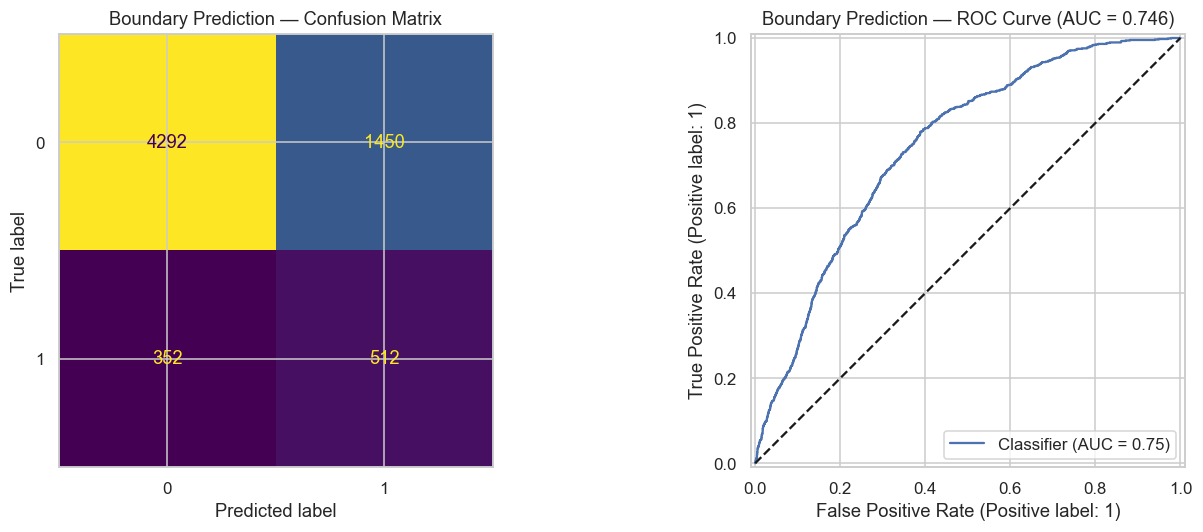

In [28]:
auc_boundary = evaluate_model(model_boundary, X_te, y_te, 'Boundary Prediction')

In [29]:
plot_feature_importance(model_boundary, FEATURES, 'Boundary Prediction')

In [30]:
# Cross-validation
cv_scores = cross_val_score(model_boundary, X, y_boundary,
                             cv=StratifiedKFold(5, shuffle=True, random_state=42),
                             scoring='roc_auc', n_jobs=-1)
print(f'5-fold CV ROC-AUC (boundary): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

5-fold CV ROC-AUC (boundary): 0.7392 ± 0.0047


In [31]:
# Save
joblib.dump(model_boundary, os.path.join(MODELS_DIR, 'predict_boundary_model.joblib'))
print('Boundary model saved.')

Boundary model saved.


## 5. Model B — Good Ball Prediction

In [32]:
y_goodball = df['isGoodBall']

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X, y_goodball, test_size=0.2, random_state=42, stratify=y_goodball
)

model_goodball = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)
model_goodball.fit(X_tr2, y_tr2)
print('Good ball model trained.')

Good ball model trained.



=== Good Ball Prediction ===
Accuracy : 0.6798
ROC-AUC  : 0.7084

              precision    recall  f1-score   support

           0      0.348     0.562     0.430      1420
           1      0.856     0.712     0.777      5186

    accuracy                          0.680      6606
   macro avg      0.602     0.637     0.604      6606
weighted avg      0.747     0.680     0.703      6606



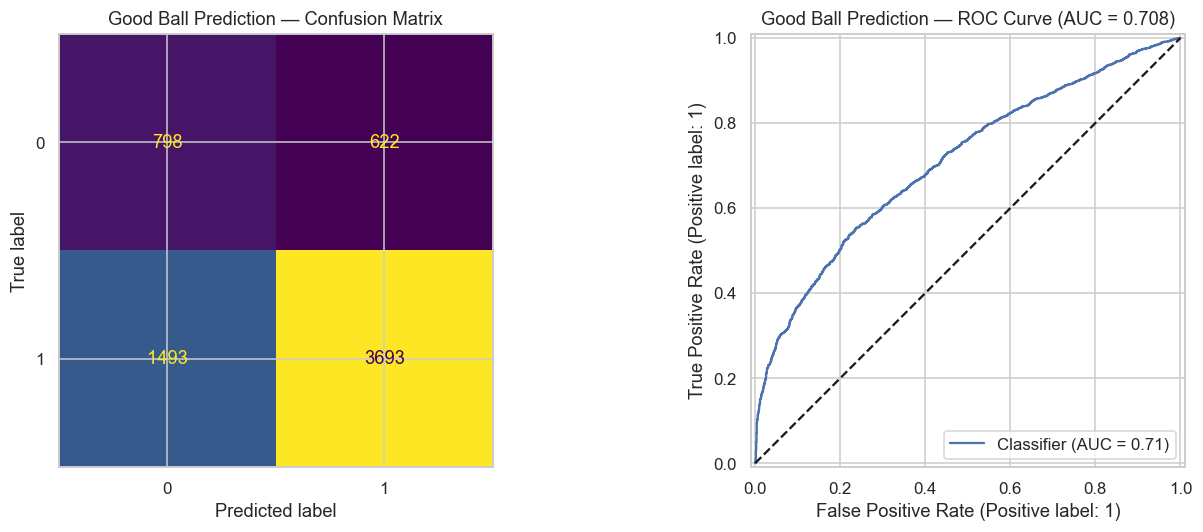

In [33]:
auc_goodball = evaluate_model(model_goodball, X_te2, y_te2, 'Good Ball Prediction')

In [34]:
plot_feature_importance(model_goodball, FEATURES, 'Good Ball Prediction')

In [35]:
# Cross-validation
cv2 = cross_val_score(model_goodball, X, y_goodball,
                       cv=StratifiedKFold(5, shuffle=True, random_state=42),
                       scoring='roc_auc', n_jobs=-1)
print(f'5-fold CV ROC-AUC (good ball): {cv2.mean():.4f} ± {cv2.std():.4f}')

5-fold CV ROC-AUC (good ball): 0.7042 ± 0.0025


In [36]:
# Save
joblib.dump(model_goodball, os.path.join(MODELS_DIR, 'predict_good_ball_model.joblib'))
print('Good ball model saved.')

Good ball model saved.


## 6. Model Comparison Summary

In [37]:
summary = pd.DataFrame({
    'Model'    : ['Boundary Prediction', 'Good Ball Prediction'],
    'ROC-AUC'  : [round(auc_boundary, 4), round(auc_goodball, 4)],
    'CV Mean'  : [cv_scores.mean().round(4), cv2.mean().round(4)],
    'CV Std'   : [cv_scores.std().round(4), cv2.std().round(4)]
})
print(summary.to_string(index=False))

fig = px.bar(summary.melt(id_vars='Model', value_vars=['ROC-AUC','CV Mean']),
             x='Model', y='value', color='variable', barmode='group',
             title='Model Performance Comparison (ROC-AUC)',
             labels={'value': 'Score', 'variable': 'Metric'},
             text_auto='.4f')
fig.update_traces(textposition='outside')
fig.update_layout(yaxis_range=[0, 1.1])
fig.show()

               Model  ROC-AUC  CV Mean  CV Std
 Boundary Prediction   0.7456   0.7392  0.0047
Good Ball Prediction   0.7084   0.7042  0.0025


## 7. Prediction Function (for Inference)

Use this function to get predictions on new deliveries.

In [38]:
def predict_delivery(
    inning_number, overs_actual, pitch_line, pitch_length,
    shot_type, time_of_day, batsman_batting_style, bowler_bowling_style,
    total_wickets=0,
    models_dir=MODELS_DIR
):
    """
    Predict whether a delivery will be a boundary or a good ball.

    Parameters
    ----------
    All string values should match exactly the values used during training.
    Call list(le.classes_) on each encoder to see valid values.

    Returns
    -------
    dict with boundary_probability and good_ball_probability.
    """
    le_dict  = joblib.load(os.path.join(models_dir, 'label_encoders.joblib'))
    m_bdry   = joblib.load(os.path.join(models_dir, 'predict_boundary_model.joblib'))
    m_good   = joblib.load(os.path.join(models_dir, 'predict_good_ball_model.joblib'))

    def safe_encode(le, val):
        if val in le.classes_:
            return le.transform([val])[0]
        print(f'Warning: "{val}" not in encoder, defaulting to 0')
        return 0

    is_death      = int(overs_actual >= 16)
    is_pp         = int(overs_actual <= 6)
    balls_bowled  = int(overs_actual) * 6 + int((overs_actual % 1) * 10)
    remaining_ov  = max((120 - balls_bowled) / 6, 0)
    pl_enc        = safe_encode(le_dict['pitchLine'],            pitch_line)
    plen_enc      = safe_encode(le_dict['pitchLength'],          pitch_length)
    shot_enc      = safe_encode(le_dict['shotType'],             shot_type)
    tod_enc       = safe_encode(le_dict['time_of_day'],          time_of_day)
    bat_enc       = safe_encode(le_dict['Batsman_Batting_Style'], batsman_batting_style)
    bwl_enc       = safe_encode(le_dict['Bowler_Bowling_Style'], bowler_bowling_style)
    pressure      = min((total_wickets + 1) / (overs_actual + 1), 5)

    row = pd.DataFrame([{
        'inningNumber': inning_number, 'oversActual': overs_actual,
        'isDeathOver': is_death, 'isPowerplay': is_pp, 'remaining_overs': remaining_ov,
        'pitchLine_enc': pl_enc, 'pitchLength_enc': plen_enc, 'line_x_length': pl_enc * plen_enc,
        'shotType_enc': shot_enc, 'Batsman_Batting_Style_enc': bat_enc,
        'Bowler_Bowling_Style_enc': bwl_enc, 'time_of_day_enc': tod_enc,
        'totalWickets': total_wickets, 'pressure_index': pressure
    }])

    p_boundary = m_bdry.predict_proba(row)[0][1]
    p_goodball = m_good.predict_proba(row)[0][1]

    return {
        'boundary_probability': round(p_boundary, 4),
        'good_ball_probability': round(p_goodball, 4),
        'prediction': 'Boundary' if p_boundary > 0.5 else ('Good Ball' if p_goodball > 0.5 else 'Normal')
    }

# Example
result = predict_delivery(
    inning_number=1, overs_actual=18.3,
    pitch_line='OUTSIDE_OFFSTUMP', pitch_length='YORKER',
    shot_type='SLOG_SHOT', time_of_day='night',
    batsman_batting_style='right-hand bat',
    bowler_bowling_style='right-arm fast'
)
print('Prediction:', result)

Prediction: {'boundary_probability': np.float64(0.4756), 'good_ball_probability': np.float64(0.4471), 'prediction': 'Normal'}
